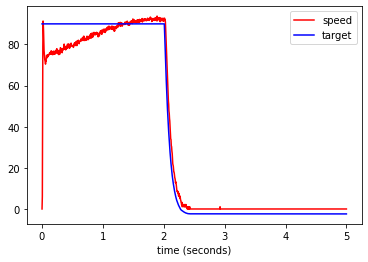

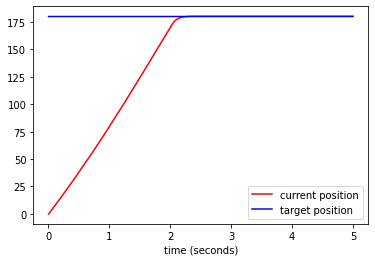

In [6]:
import sys
sys.path.append("../../")

import time
import math

from lib.data.dataplot import *
from lib.utils.time import *
from lib.system.basic import *
from lib.system.controllers import *
from lib.hardware.motor_driver import *

class PositionSpeedControl:
    
    def __init__(self, kp_pos, sat_pos, kp_speed, ki_speed, sat_speed):
        self.position_controller = P_Controller(kp_pos, sat_pos)
        self.speed_controller = PI_Controller(kp_speed, ki_speed, sat_speed)
        self.target_pos = 0
        self.target_speed = 0
        
    def set_target_position(self, p):
        self.target_pos = p
        
    def evaluate(self, delta_t, current_pos, current_speed):
        pos_error = self.target_pos - current_pos
        self.target_speed = self.position_controller.evaluate(delta_t, pos_error)
        
        speed_error = self.target_speed - current_speed
        out = self.speed_controller.evaluate(delta_t, speed_error)
        return out

dvel = DataPlotter()
dvel.set_x("time (seconds)")
dvel.add_y("speed", "speed")
dvel.add_y("target", "target")

dpos = DataPlotter()
dpos.set_x("time (seconds)")
dpos.add_y("position", "current position")
dpos.add_y("target", "target position")


m = MotorDriver()
m.open()

d = Derivator()

target_position = 180.0
ctrl = PositionSpeedControl(10.0,  # KP pos 
                            90.0, # pos output saturation (max speed deg/s) 
                            30.0,  # KP speed
                            20.0,  # KI speed
                            4200)  # speed output saturation (max motor power)
ctrl.set_target_position(target_position)

tm = Time()
tm.start()
while tm.get() < 5:

    delta_t = tm.elapsed()
    
    position = m.encoder()
    speed = d.evaluate(delta_t, position)
    
    position = position * 360/84000
    speed = speed * 360/84000
    
    output = ctrl.evaluate(delta_t, position, speed)
    
    m.pwm(output) # range [-4200, 4200]
    
    dvel.append_x(tm.get())
    dvel.append_y("speed", speed)
    dvel.append_y("target", ctrl.target_speed)

    dpos.append_x(tm.get())
    dpos.append_y("position", position)
    dpos.append_y("target", target_position)
    
    
m.pwm(0)
dvel.plot()
dpos.plot()
